## 1. What this notebook computes

Notebook 11b computed the three Lovelock tensors $P_{(1)}, P_{(2)}, P_{(3)}$ of the
author's metric and found that only their eight diagonal components are not zero.
This notebook studies those components: what they look like, which structure they
have, and how they behave as the extra times deflate. It

- reads the exact components from the Revision record `lovelock-tensors.json` and
  forms the normalised tensors $E_{(k)} = -P_{(k)}/2^{k+1}$ ($E_{(1)}$ is Einstein's
  tensor $G$), and checks that they are the components recorded for the field
  equations of $a_4$ in `Revision/field_equations_a4/a4-equations.json`;
- proves with sympy their structure: the three space components are equal, the three
  extra-time components are equal, the time component contains no $a_4''$, the
  difference of the space and the extra-time component is $a_4''$ times a
  polynomial, the hidden component is the mean of the two, every component is
  unchanged when $a_4'$ changes sign, and every term of order $k$ is $2k$ powers of
  an inverse length;
- derives and checks the two conservation identities (the Bianchi identities) that
  every Lovelock tensor obeys in this metric;
- draws the components and the Lovelock scalars along the exponentially deflating
  history $a_4 = A H x_4$, as functions of $A$; and along an illustrative test
  history in which the deflation speeds up, to show where $a_4''$ enters, with a
  numerical check of the conservation identity along it.

It draws five figures and takes about 15 seconds.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 11c (The Lovelock tensors along the deflating history: components and
identities) is the file `Revision/textbook/notebooks/11c_lovelock_components.ipynb` of
the repository Dirac_claude. It reads the exact components of the three Lovelock tensors
of the author's metric from the Revision record, writes the normalised tensors E(1) (the
Einstein tensor), E(2) and E(3) as polynomials in H and in the first and second time
derivatives of a4, reproduces the components recorded for the field equations of a4,
proves with sympy their structure (equal components within ordinary space and within the
extra times, a time component without second derivatives, a space minus extra-time
difference proportional to the second derivative, a hidden component equal to the mean of
the two, evenness in the first derivative, the order of each term) and the two
conservation identities, and plots every component and the three Lovelock scalars along
the exponentially deflating linear history a4 = A H x4 and along an illustrative test
history; it draws five figures. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 11c_lovelock_components.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 11c_lovelock_components.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
11c_lovelock_components.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/11c.captions.json`
- `Revision/textbook/figures/11c_1_components_linear_history.png`
- `Revision/textbook/figures/11c_2_lovelock_scalars.png`
- `Revision/textbook/figures/11c_3_test_history.png`
- `Revision/textbook/figures/11c_4_components_test_history.png`
- `Revision/textbook/figures/11c_5_conservation_identity.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all five figure files of the notebook exist
    ALL 16 CHECKS PASSED (notebook 11c)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/11c_lovelock_components.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 11c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 11c (The Lovelock tensors along the deflating history: components and
# identities) is the file Revision/textbook/notebooks/11c_lovelock_components.ipynb of
# the repository Dirac_claude. It reads the exact components of the three Lovelock
# tensors of the author's metric from the Revision record, writes the normalised tensors
# E(1) (the Einstein tensor), E(2) and E(3) as polynomials in H and in the first and
# second time derivatives of a4, reproduces the components recorded for the field
# equations of a4, proves with sympy their structure (equal components within ordinary
# space and within the extra times, a time component without second derivatives, a space
# minus extra-time difference proportional to the second derivative, a hidden component
# equal to the mean of the two, evenness in the first derivative, the order of each term)
# and the two conservation identities, and plots every component and the three Lovelock
# scalars along the exponentially deflating linear history a4 = A H x4 and along an
# illustrative test history; it draws five figures. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 11c_lovelock_components.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 11c_lovelock_components.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 11c_lovelock_components.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/11c.captions.json
# - Revision/textbook/figures/11c_1_components_linear_history.png
# - Revision/textbook/figures/11c_2_lovelock_scalars.png
# - Revision/textbook/figures/11c_3_test_history.png
# - Revision/textbook/figures/11c_4_components_test_history.png
# - Revision/textbook/figures/11c_5_conservation_identity.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all five figure files of the notebook exist
#     ALL 16 CHECKS PASSED (notebook 11c)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/11c_lovelock_components.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "11c"  # this notebook: chapter 11, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 11c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$: $x_1, x_2, x_3$ ordinary space, $x_4$ the time,
  $x_5, x_6, x_7$ the three extra times, $x_8$ the hidden direction.
- **History** $a_4(x_4)$: the function of the time in the author's metric. The
  scale factor of ordinary space is $e^{a_4}$, that of the extra times $e^{-a_4}$
  (times the same factor $\sin^{1/6} z$ of the hidden direction). If $a_4$ grows,
  space **inflates** and the extra times **deflate**.
- **Linear history** $a_4 = A H x_4$ with a constant number $A$: then
  $a_4' = AH$ and $a_4'' = 0$, and the extra times shrink like $e^{-AHx_4}$:
  exponential deflation for $A > 0$.
- $a_4'$, $a_4''$: the first and second derivatives of $a_4$ with respect to the time
  $x_4$. In code they are the symbols `A1` and `A2`.
- **Component** $E^h{}_j$: the number in row $h$ and column $j$ of a tensor;
  $E^{x_1}{}_{x_1}$ is written $E^{x1}_{x1}$ in printed text.
- **Lovelock tensor** $P_{(k)}$, **normalised Lovelock tensor**
  $E_{(k)} = -P_{(k)}/2^{k+1}$, **Lovelock scalar** $L_{(k)}$: built from the
  curvature with the generalized Kronecker delta (Notebooks 11a and 11b).
- **Covariant divergence** $\nabla_h E^h{}_j$: the derivative of a tensor that takes
  the curving of the coordinates into account (through the Christoffel symbols).
  **Bianchi identity**: the statement that it is zero for every Lovelock tensor.
- **Even function**: $f(-u) = f(u)$. **Polynomial in** $u$: a sum of numbers times
  powers $u^n$.
- **Finite difference**: the approximation $f'(t) \approx (f(t + \epsilon) -
  f(t - \epsilon))/(2\epsilon)$ of a derivative.
- **Illustration**: a choice made only to show how a formula behaves; it is not a
  result and not a solution of any equation.

## 4. The physical and mathematical situation

**The tensors.** For the author's metric (Notebook 11b) the Lovelock tensors
$P_{(k)}{}^h{}_j$, $k = 1, 2, 3$, are diagonal, contain only $H$, $a_4'$ and
$a_4''$, and do not depend on $x_8$. The field equations of $a_4$ (chapter 12) use
the normalised tensors

$$E_{(k)}{}^h{}_j = -\frac{1}{2^{k+1}}\, P_{(k)}{}^h{}_j ,\qquad
  \sum_{k=1}^{3} \alpha_k E_{(k)}{}^\mu{}_\nu + \Lambda\,\delta^\mu_\nu
  = \kappa\, T^\mu{}_\nu ,$$

with $E_{(1)} = G$, Einstein's tensor. The independent components are
$E^{x1}_{x1}$ (equal to $E^{x2}_{x2}$ and $E^{x3}_{x3}$: ordinary space),
$E^{x4}_{x4}$ (the time), $E^{x5}_{x5}$ (equal to $E^{x6}_{x6}$ and $E^{x7}_{x7}$:
the extra times) and $E^{x8}_{x8}$ (the hidden direction).

**The two conservation identities, derived line by line.** Every Lovelock tensor has
zero covariant divergence (Lovelock's theorem; the Revision checked it exactly). For
a diagonal tensor that depends only on $x_4$ the divergence is

$$\nabla_h P^h{}_j = \partial_h P^h{}_j + \sum_{h,m} \Gamma^h{}_{hm} P^m{}_j
  - \sum_{h,m} \Gamma^m{}_{hj} P^h{}_m .$$

Take $j = x_4$. The first term is $\partial_4 P^4{}_4$ (only $h = x_4$ survives,
because $P^h{}_4 = 0$ for $h \ne x_4$). In the second term only $m = x_4$ survives:
$\sum_h \Gamma^h{}_{h4} P^4{}_4$. In the third, $P^h{}_m$ is diagonal, so $m = h$:
$\sum_h \Gamma^h{}_{h4} P^h{}_h$. Hence

$$\nabla_h P^h{}_4 = \partial_4 P^4{}_4 + \sum_h \Gamma^h{}_{h4}
  \big(P^4{}_4 - P^h{}_h\big).$$

The Christoffel symbols of the metric (Notebook 11b) are $\Gamma^h{}_{h4} = a_4'$ for
the three space directions, $-a_4'$ for the three extra times, and 0 for $x_4$ and
$x_8$. So the sum is $3a_4'(P^4{}_4 - P^1{}_1) - 3a_4'(P^4{}_4 - P^5{}_5) =
-3a_4'(P^1{}_1 - P^5{}_5)$, and the identity reads

$$\frac{d}{dx_4} E^{x4}{}_{x4} = 3\, a_4'\, \big(E^{x1}{}_{x1} - E^{x5}{}_{x5}\big).
  \qquad (\text{I})$$

Take $j = x_8$. Nothing depends on $x_8$, and the same steps give
$\sum_h \Gamma^h{}_{h8}(P^8{}_8 - P^h{}_h)$ with $\Gamma^h{}_{h8} = H \cot z$ for the
three space and the three extra-time directions, 0 for $x_4$, and the term $h = x_8$
is zero because $P^8{}_8 - P^8{}_8 = 0$. So $3H\cot z\,(2P^8{}_8 - P^1{}_1 -
P^5{}_5) = 0$, that is

$$E^{x8}{}_{x8} = \tfrac12 \big(E^{x1}{}_{x1} + E^{x5}{}_{x5}\big).
  \qquad (\text{II})$$

The divergences along $x_1, x_2, x_3, x_5, x_6, x_7$ vanish because nothing depends
on these coordinates and the tensors are diagonal. In the field equations (I) becomes
the conservation of energy, $\rho' = -3a_4'(p_3 - p_t)$, and (II) the condition
$p_3 + p_t = 2p_8$ on the pressures (chapter 12).

**Status.** The components are PROVED by exact computation (Revision records); the
structure and the identities are PROVED here with sympy; the test history of
section 9 is an ILLUSTRATION, not a solution of the field equations.

## 5. The components, from the Revision record

The next cell reads `lovelock-tensors.json`, which lists every component of
$P_{(k)}$ as exact monomials `[numerator, denominator, [e_H, e_a4', e_a4'', e_a4''',
e_a4'''', e_E, e_S, e_C]]` (the exponents of $H$, of the four derivatives of $a_4$,
of $e^{a_4}$, of $\sin^{1/3} z$ and of $\cot z$). It rebuilds each component as a
sympy expression in `H`, `A1` ($a_4'$) and `A2` ($a_4''$); if any other exponent
were not zero the cell would stop, so the components are free of $x_8$, of
$e^{a_4}$ and of higher derivatives. It forms $E_{(k)} = -P_{(k)}/2^{k+1}$ and
prints the four independent components of each order.

In [2]:
import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra

H, A1, A2 = sp.symbols("H A1 A2")  # H, a4' and a4''
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
tensors = json.loads(repository_file(
    "Revision/gkd_lovelock/results/lovelock-tensors.json").read_text(encoding="utf-8"))


def from_monomials(monomials):
    """A component of lovelock-tensors.json as a sympy expression in H, A1, A2."""
    total = sp.Integer(0)
    for numerator, denominator, e in monomials:
        if any(e[3:]):  # 3rd or 4th derivative, e^a4, sin^(1/3) z or cot z
            raise ValueError("the component contains more than H, a4' and a4''")
        monomial = H ** e[0] * A1 ** e[1] * A2 ** e[2]  # H^eH a4'^e1 a4''^e2
        total += sp.Rational(numerator, denominator) * monomial
    return total


P = {k: {(h, j): from_monomials(tensors[f"P{k}_mixed_up_h_down_j"][f"{a},{b}"]
                                ["monomials"])
         for h, a in enumerate(NAMES) for j, b in enumerate(NAMES)} for k in (1, 2, 3)}
E = {k: {hj: sp.expand(-value / 2 ** (k + 1)) for hj, value in P[k].items()}
     for k in (1, 2, 3)}
for k in (1, 2, 3):
    for h in (0, 3, 4, 7):  # x1, x4, x5, x8
        say(f"E({k})^{NAMES[h]}_{NAMES[h]} = {E[k][h, h]}")
check(all(E[k][h, j] == 0 for k in (1, 2, 3) for h in range(8) for j in range(8)
          if h != j),
      "every off-diagonal component of E(1), E(2), E(3) is zero, x4-x8 included")

E(1)^x1_x1 = -3*A1**2 + A2 + 15*H**2
E(1)^x4_x4 = 3*A1**2 + 21*H**2
E(1)^x5_x5 = -3*A1**2 - A2 + 15*H**2
E(1)^x8_x8 = -3*A1**2 + 15*H**2
E(2)^x1_x1 = 12*A1**4 - 24*A1**2*A2 + 168*A1**2*H**2 - 40*A2*H**2 - 180*H**4
E(2)^x4_x4 = -36*A1**4 - 120*A1**2*H**2 - 420*H**4
E(2)^x5_x5 = 12*A1**4 + 24*A1**2*A2 + 168*A1**2*H**2 + 40*A2*H**2 - 180*H**4
E(2)^x8_x8 = 12*A1**4 + 168*A1**2*H**2 - 180*H**4
E(3)^x1_x1 = -72*A1**6 + 360*A1**4*A2 - 648*A1**4*H**2 + 432*A1**2*A2*H**2 -
    1944*A1**2*H**4 + 360*A2*H**4 + 360*H**6
E(3)^x4_x4 = 360*A1**6 + 648*A1**4*H**2 + 1080*A1**2*H**4 + 2520*H**6
E(3)^x5_x5 = -72*A1**6 - 360*A1**4*A2 - 648*A1**4*H**2 - 432*A1**2*A2*H**2 -
    1944*A1**2*H**4 - 360*A2*H**4 + 360*H**6
E(3)^x8_x8 = -72*A1**6 - 648*A1**4*H**2 - 1944*A1**2*H**4 + 360*H**6
PASS every off-diagonal component of E(1), E(2), E(3) is zero, x4-x8 included


The next cell compares these components with two other Revision records. The record
`a4-equations.json` of the field equations of $a_4$ (written by the Revision's
Wolfram derivation and checked by its sympy checker) lists $E_{(1)}, E_{(2)},
E_{(3)}$ in the entry `lovelockTensors`, in Wolfram's input notation with `ad1` for
$a_4'$ and `ad2` for $a_4''$. The record `python-lovelock-report.json` lists the
nonzero components of $P_{(k)}$ in its entry `independentResults`. Both texts are
turned into sympy expressions with `sp.sympify` (`^` is first replaced by `**`).

In [3]:
a4_record = json.loads(repository_file(
    "Revision/field_equations_a4/a4-equations.json").read_text(encoding="utf-8"))
WOLFRAM_NAMES = {"ad1": A1, "ad2": A2, "H": H}


def from_text(text):
    """A formula of the records as a sympy expression in H, A1, A2."""
    return sp.sympify(text.replace("^", "**"), locals=WOLFRAM_NAMES)


same = True
for k in (1, 2, 3):
    listed = a4_record["lovelockTensors"][f"E{k}"]
    for key, (h, j) in (("x1x1", (0, 0)), ("x4x4", (3, 3)), ("x5x5", (4, 4)),
                        ("x8x8", (7, 7)), ("x4x8", (3, 7)), ("x8x4", (7, 3))):
        same = same and sp.expand(from_text(listed[key]["input"]) - E[k][h, j]) == 0
check(same, "E(1), E(2), E(3) equal the components recorded for the a4 equations",
      record="Revision/field_equations_a4/reports/python-a4-report.json, check "
             "json_lovelock_components")
checker = json.loads(repository_file(
    "Revision/gkd_lovelock/results/python-lovelock-report.json").read_text(
        encoding="utf-8"))
independent = checker["independentResults"]
same = all(
    sp.expand(sp.sympify(text, locals={"A1": A1, "A2": A2, "H": H})
              - P[k][NAMES.index(key.split(",")[0]), NAMES.index(key.split(",")[1])])
    == 0
    for k in (1, 2, 3) for key, text in independent[f"P{k}_mixed_nonzero"].items())
check(same and all(len(independent[f"P{k}_mixed_nonzero"]) == 8 for k in (1, 2, 3)),
      "P(1), P(2), P(3) equal the independent sympy results (8 nonzero components each)",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, "
             "independentResults")

PASS E(1), E(2), E(3) equal the components recorded for the a4 equations
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_lovelock_components
PASS P(1), P(2), P(3) equal the independent sympy results (8 nonzero components each)
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json,
    independentResults


## 6. The structure of the components

The next cell proves, for $k = 1, 2, 3$, with exact sympy algebra:

1. $E^{x1}_{x1} = E^{x2}_{x2} = E^{x3}_{x3}$ and $E^{x5}_{x5} = E^{x6}_{x6} =
   E^{x7}_{x7}$: the three space directions are alike, and so are the three extra
   times.
2. $E^{x4}_{x4}$ and $E^{x8}_{x8}$ contain no $a_4''$ (`expr.has(A2)` is False): the
   time component of the field equations is a condition on $a_4'$ only (a
   constraint), not an equation for its change.
3. $E^{x1}_{x1} - E^{x5}_{x5} = a_4''\, F_k(a_4')$ with a polynomial $F_k$ that
   contains no $a_4''$ (`sp.cancel` divides exactly, and the quotient must be free
   of `A2`): this difference is the only place where $a_4''$ appears, so it is the
   equation that decides how $a_4$ changes (the evolution equation of chapter 12).
   The record `a4-equations.json` lists
   $F = \alpha_1 F_1 + \alpha_2 F_2 + \alpha_3 F_3$ in its entry `evolution_F`; the
   cell compares the coefficient of each $\alpha_k$.
4. $E^{x8}_{x8} = \tfrac12 (E^{x1}_{x1} + E^{x5}_{x5})$: identity (II).
5. Every component is even in $a_4'$: replacing $a_4'$ by $-a_4'$ changes nothing.
   Inflating ordinary space with deflating extra times ($a_4' > 0$) and the reverse
   ($a_4' < 0$) give the same components: deflation is a choice of sign that these
   tensors do not select.
6. Every term of $E_{(k)}$ has the **weight** $2k$, where $H$ and $a_4'$ count 1 and
   $a_4''$ counts 2 (each is one inverse length per count): order $k$ has the
   dimension $1/\text{length}^{2k}$. So the three orders can be added in one field
   equation only with constants $\alpha_k$ of different dimensions, for example
   $\alpha_k = w_k / H^{2k - 2}$ with pure numbers $w_k$.

In [4]:
u = sp.Symbol("u")  # an auxiliary number used to test the weights
F = {}  # k -> F_k(a4')
alphas = sp.symbols("alpha1 alpha2 alpha3")  # the constants of the a4 equations
recorded_F = sp.sympify(
    a4_record["generalSource"]["evolution_F"]["input"].replace("^", "**"),
    locals={"ad1": A1, "H": H, "alpha1": alphas[0], "alpha2": alphas[1],
            "alpha3": alphas[2]})
structure = {name: True for name in ("alike", "constraint", "evolution", "mean",
                                     "even", "weight")}
for k in (1, 2, 3):
    e = E[k]
    structure["alike"] &= (e[0, 0] == e[1, 1] == e[2, 2]
                           and e[4, 4] == e[5, 5] == e[6, 6])
    structure["constraint"] &= not e[3, 3].has(A2) and not e[7, 7].has(A2)
    F[k] = sp.factor(sp.cancel((e[0, 0] - e[4, 4]) / A2))
    structure["evolution"] &= (not F[k].has(A2)
                               and sp.expand(F[k] - recorded_F.coeff(alphas[k - 1]))
                               == 0)
    structure["mean"] &= sp.expand(e[7, 7] - (e[0, 0] + e[4, 4]) / 2) == 0
    structure["even"] &= all(sp.expand(e[h, h].subs(A1, -A1) - e[h, h]) == 0
                             for h in range(8))
    weighted = {h: sp.expand(e[h, h].subs({H: u * H, A1: u * A1, A2: u ** 2 * A2}))
                for h in range(8)}
    structure["weight"] &= all(sp.expand(weighted[h] - u ** (2 * k) * e[h, h]) == 0
                               for h in range(8))
    report(f"F_{k}(a4') = (E({k})^x1_x1 - E({k})^x5_x5) / a4''", F[k])
check(structure["alike"], "space components equal, extra-time components equal")
check(structure["constraint"], "the x4 and x8 components contain no a4''")
check(structure["evolution"],
      "E^x1_x1 - E^x5_x5 = a4'' F_k(a4') with F_1 = 2, F_2 = -16 (3 a4'^2 + 5 H^2), "
      "F_3 = 144 (5 a4'^4 + 6 a4'^2 H^2 + 5 H^4)",
      record="Revision/field_equations_a4/reports/python-a4-report.json, check "
             "evolution_factorises (a4-equations.json, evolution_F)")
check(structure["mean"], "E^x8_x8 is the mean of E^x1_x1 and E^x5_x5 (identity II)")
check(structure["even"] and structure["weight"],
      "every component is even in a4' and of weight 2k (dimension 1/length^(2k))")

RESULT F_1(a4') = (E(1)^x1_x1 - E(1)^x5_x5) / a4'' = 2
RESULT F_2(a4') = (E(2)^x1_x1 - E(2)^x5_x5) / a4'' = -16*(3*A1**2 + 5*H**2)
RESULT F_3(a4') = (E(3)^x1_x1 - E(3)^x5_x5) / a4'' = 144*(5*A1**4 + 6*A1**2*H**2 +
    5*H**4)
PASS space components equal, extra-time components equal
PASS the x4 and x8 components contain no a4''
PASS E^x1_x1 - E^x5_x5 = a4'' F_k(a4') with F_1 = 2, F_2 = -16 (3 a4'^2 + 5 H^2), F_3 =
    144 (5 a4'^4 + 6 a4'^2 H^2 + 5 H^4)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    evolution_factorises (a4-equations.json, evolution_F)
PASS E^x8_x8 is the mean of E^x1_x1 and E^x5_x5 (identity II)
PASS every component is even in a4' and of weight 2k (dimension 1/length^(2k))


## 7. The conservation identity along the time

Identity (I) of section 4 says $\frac{d}{dx_4} E^{x4}_{x4} = 3a_4'(E^{x1}_{x1} -
E^{x5}_{x5})$. The time component depends on $x_4$ only through $a_4'$, so by the
chain rule $\frac{d}{dx_4} E^{x4}_{x4} = \frac{\partial E^{x4}_{x4}}{\partial a_4'}
\, a_4''$. The next cell checks the identity exactly for $k = 1, 2, 3$ with
`sp.diff(..., A1) * A2`. With section 6 it says
$\partial E^{x4}_{x4}/\partial a_4' = 3 a_4' F_k(a_4')$: the derivative of the
constraint is $3a_4'$ times the evolution factor, the "constraint propagation" of
the Revision record. The cell also checks the factorisation
$E^{x4}_{x4} - E^{x8}_{x8} = 6(a_4'^2 + H^2)\, V_k(a_4')$, with the polynomials $V_1 =
1$, $V_2 = -8(a_4'^2 + 5H^2)$, $V_3 = 72(a_4'^4 + 2a_4'^2 H^2 + 5H^4)$, which the
Revision record of the field equations uses for the linear history
(check `linear_member_vacuum_factor`).

In [5]:
V = {1: sp.Integer(1), 2: -8 * (A1 ** 2 + 5 * H ** 2),
     3: 72 * (A1 ** 4 + 2 * A1 ** 2 * H ** 2 + 5 * H ** 4)}
identity_I = all(
    sp.expand(sp.diff(E[k][3, 3], A1) * A2 - 3 * A1 * (E[k][0, 0] - E[k][4, 4])) == 0
    for k in (1, 2, 3))
check(identity_I, "d/dx4 E^x4_x4 = 3 a4' (E^x1_x1 - E^x5_x5) for k = 1, 2, 3 "
                  "(identity I)",
      record="Revision/field_equations_a4/reports/python-a4-report.json, check "
             "bianchi_x4; Revision/gkd_lovelock/results/lovelock-report.json, checks "
             "k1/k2/k3_divergence_free")
factor_ok = all(sp.expand(E[k][3, 3] - E[k][7, 7] - 6 * (A1 ** 2 + H ** 2) * V[k]) == 0
                for k in (1, 2, 3))
check(factor_ok, "E^x4_x4 - E^x8_x8 = 6 (a4'^2 + H^2) V_k for k = 1, 2, 3",
      record="Revision/field_equations_a4/reports/python-a4-report.json, check "
             "linear_member_vacuum_factor")

PASS d/dx4 E^x4_x4 = 3 a4' (E^x1_x1 - E^x5_x5) for k = 1, 2, 3 (identity I)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    bianchi_x4; Revision/gkd_lovelock/results/lovelock-report.json, checks
    k1/k2/k3_divergence_free
PASS E^x4_x4 - E^x8_x8 = 6 (a4'^2 + H^2) V_k for k = 1, 2, 3
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    linear_member_vacuum_factor


## 8. Along the exponentially deflating history $a_4 = A H x_4$

On the linear history $a_4' = AH$ and $a_4'' = 0$. Then every component is $H^{2k}$
times a polynomial in $A$, and the plots below show $E_{(k)}{}^h{}_h / H^{2k}$
against $A$ from $-3$ to $3$ ($A > 0$: the extra times deflate exponentially, the
author's case; $A < 0$: they would inflate; $A = 0$, where $a_4$ is constant, is the
mirror point between the two). Because $a_4'' = 0$, the space, extra-time and
hidden components coincide (section 6, items 3 and 4), so each panel has two curves:
the time component $E^{x4}_{x4}$ and the common component of the seven other
directions. `sp.lambdify` turns a sympy expression into a numpy function that can
be evaluated on an array of values of $A$. The check confirms that the two curves
are mirror-symmetric about $A = 0$.

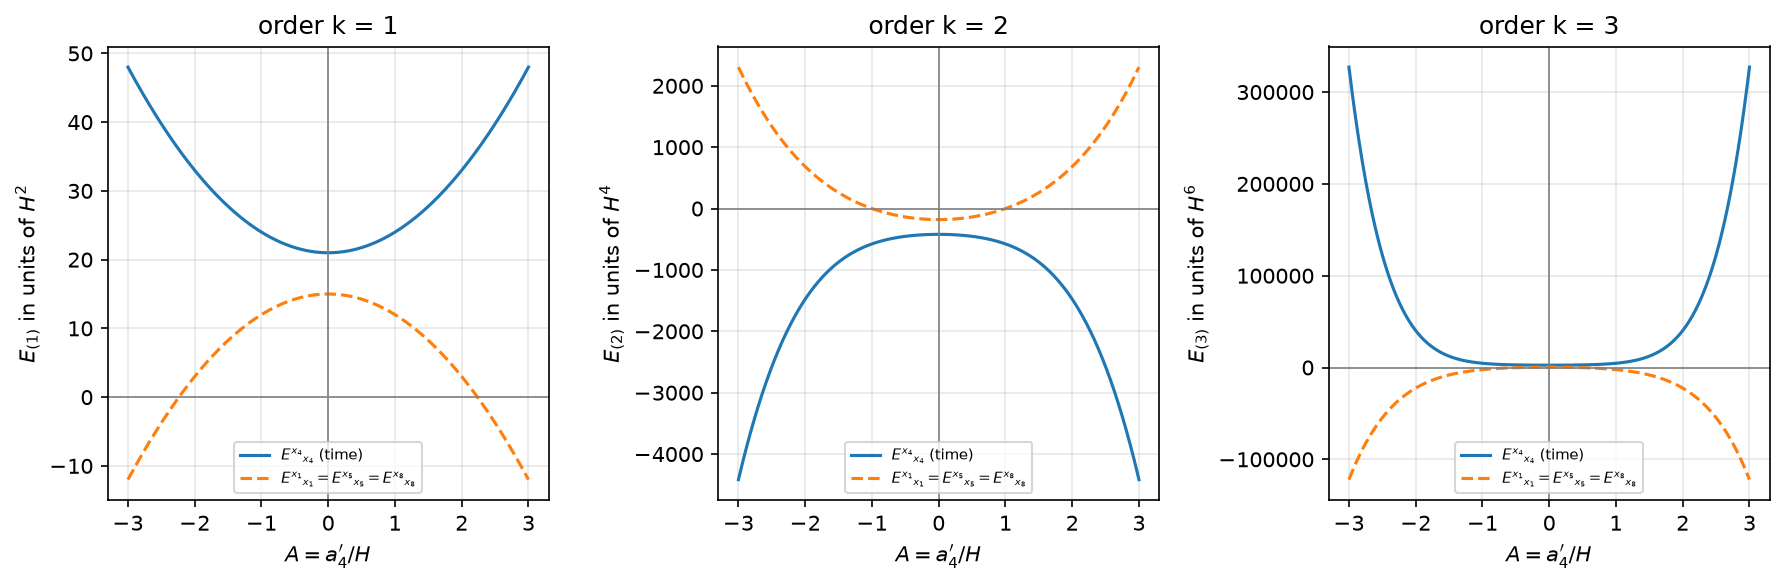

Figure 11c.1 saved as Revision/textbook/figures/11c_1_components_linear_history.png
PASS on the linear history every curve is symmetric under A -> -A


In [6]:
A = np.linspace(-3.0, 3.0, 601)  # values of A
LINEAR = {H: 1, A2: 0}  # H = 1 (units of H) and a4'' = 0; then a4' = A


def on_linear_history(expr):
    """expr / H^(2k) on the linear history, as numbers for every A."""
    function = sp.lambdify(A1, expr.subs(LINEAR), "numpy")
    return np.broadcast_to(function(A), A.shape).astype(float)


fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.0))
symmetric = True
for ax, k in zip(axes, (1, 2, 3)):
    time_part = on_linear_history(E[k][3, 3])
    other_part = on_linear_history(E[k][0, 0])
    symmetric &= np.allclose(time_part, time_part[::-1]) and np.allclose(
        other_part, other_part[::-1])
    ax.plot(A, time_part, label="$E^{x_4}{}_{x_4}$ (time)")
    ax.plot(A, other_part, "--", label="$E^{x_1}{}_{x_1} = E^{x_5}{}_{x_5} = "
                                       "E^{x_8}{}_{x_8}$")
    ax.axvline(0.0, color="0.5", lw=0.8)
    ax.axhline(0.0, color="0.5", lw=0.8)
    ax.set_xlabel("$A = a_4^{\\prime}/H$")
    ax.set_ylabel(f"$E_{{({k})}}$ in units of $H^{{{2 * k}}}$")
    ax.set_title(f"order k = {k}")
    ax.legend(fontsize=7, loc="best")
fig.tight_layout()
save_figure(fig, "components_linear_history",
            "The normalised Lovelock tensors $E_{(1)}$ (Einstein), $E_{(2)}$ and "
            "$E_{(3)}$ of the author's metric along the linear history "
            "$a_4 = A H x_4$, in units of $H^2$, $H^4$ and $H^6$, against "
            "$A = a_4^{\\prime}/H$: the time component (solid) and the common "
            "component of the space, extra-time and hidden directions (dashed), "
            "which coincide because $a_4^{\\prime\\prime} = 0$. Every curve is "
            "symmetric about $A = 0$: exponential deflation of the extra times "
            "($A > 0$) and their inflation ($A < 0$) give the same tensors. For "
            "$k = 1$ the curves are $3A^2 + 21$ and $15 - 3A^2$.")
check(symmetric, "on the linear history every curve is symmetric under A -> -A")

The next cell draws the three Lovelock scalars $L_{(k)}$ (read from the record) on
the linear history, in units of $H^{2k}$, and computes where they are zero. On the
linear history $L_{(k)}/H^{2k}$ is a polynomial in $A$; `sp.Poly(...).nroots()`
computes all its roots numerically (15 digits), and the cell keeps the real positive
ones (the negative ones are their mirror images). For $k = 1$,
$L_{(1)} = 2R = 12a_4'^2 - 84H^2$ is zero exactly at $A = \sqrt{7} \approx 2.646$.
The scalar of order 3 grows so fast ($A^6$) that its dip near $A = 0$ cannot be
seen at the scale of the whole panel, so the cell adds a small magnified panel
(`ax.inset_axes`, a panel inside a panel, placed by its left edge, bottom edge,
width and height as fractions of the big panel) for $-1 \le A \le 1$.

L(1) = 12*A1**2 - 84*H**2
RESULT positive zero of L(1) on the linear history (and minus it), A = 2.6458
L(2) = -96*A1**4 - 2112*A1**2*H**2 + 3360*H**4
RESULT positive zero of L(2) on the linear history (and minus it), A = 1.2207
L(3) = 1152*A1**6 + 31104*A1**4*H**2 + 100224*A1**2*H**4 - 40320*H**6
RESULT positive zero of L(3) on the linear history (and minus it), A = 0.6010


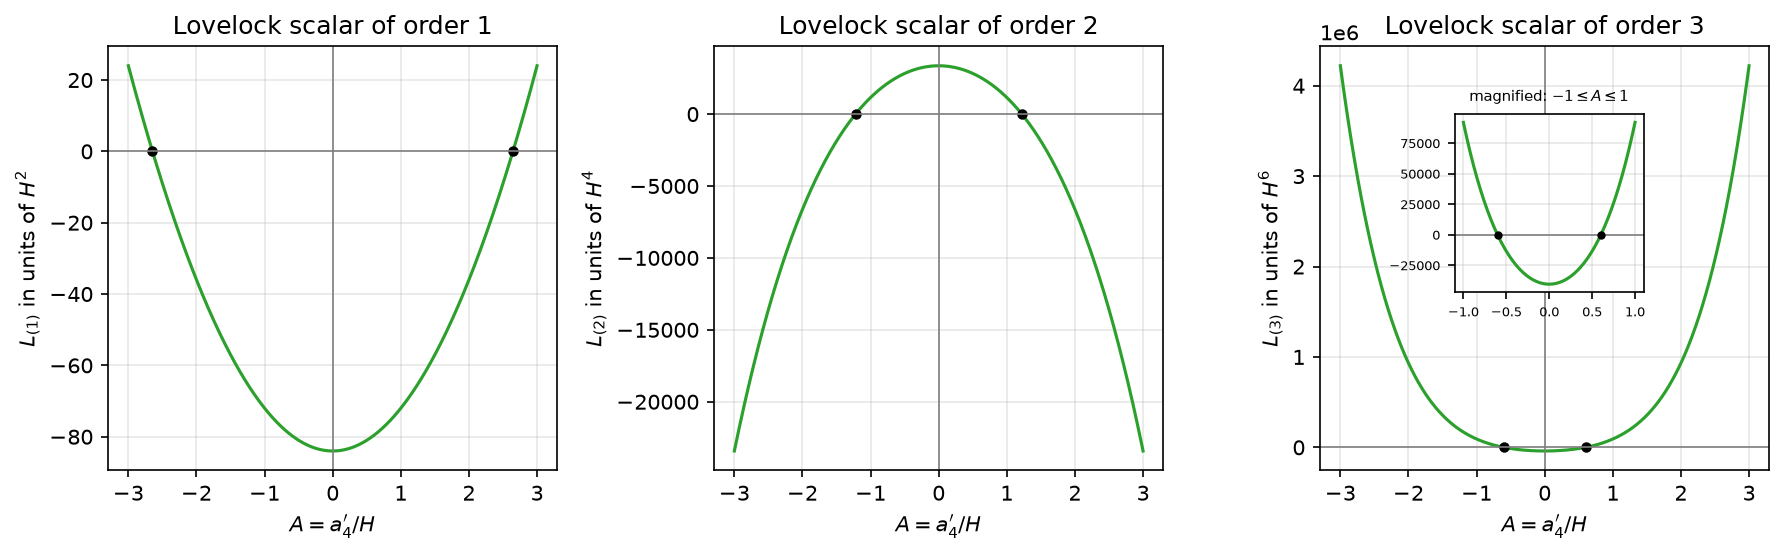

Figure 11c.2 saved as Revision/textbook/figures/11c_2_lovelock_scalars.png
PASS each scalar has one positive zero, L(1) at A = sqrt(7); at A = 0 the scalars are
    -84, 3360, -40320


In [7]:
L = {k: sp.sympify(tensors[f"L{k}"].replace("Derivative[1][a4][x4]", "A1")
                   .replace("^", "**"), locals={"A1": A1, "H": H}) for k in (1, 2, 3)}
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8))
zeros = {}
for ax, k in zip(axes, (1, 2, 3)):
    values = on_linear_history(L[k])
    roots = sp.Poly(L[k].subs(H, 1), A1).nroots(n=15)  # every root, numerically
    zeros[k] = [float(r) for r in roots if r.is_real and r > 0]
    listed = ", ".join(f"{r:.4f}" for r in zeros[k])  # the zeros, 4 decimals
    say(f"L({k}) = {L[k]}")
    report(f"positive zero of L({k}) on the linear history (and minus it), A", listed)
    ax.plot(A, values, color="tab:green")
    for r in zeros[k]:
        ax.plot([r, -r], [0.0, 0.0], "o", color="black", markersize=4)
    ax.axhline(0.0, color="0.5", lw=0.8)
    ax.axvline(0.0, color="0.5", lw=0.8)
    ax.set_xlabel("$A = a_4^{\\prime}/H$")
    ax.set_ylabel(f"$L_{{({k})}}$ in units of $H^{{{2 * k}}}$")
    ax.set_title(f"Lovelock scalar of order {k}")
    if k == 3:  # a magnified view of the middle, where the zeros of L(3) lie
        zoom = ax.inset_axes([0.30, 0.42, 0.42, 0.42])  # [left, bottom, width, height]
        near = np.abs(A) <= 1.0  # the values of A between -1 and 1
        zoom.plot(A[near], values[near], color="tab:green")
        zoom.axhline(0.0, color="0.5", lw=0.8)
        for r in zeros[k]:
            zoom.plot([r, -r], [0.0, 0.0], "o", color="black", markersize=3)
        zoom.tick_params(labelsize=6)
        zoom.set_title("magnified: $-1 \\leq A \\leq 1$", fontsize=7)
fig.tight_layout()
save_figure(fig, "lovelock_scalars",
            "The Lovelock scalars $L_{(1)} = 2R = 12 a_4^{\\prime 2} - 84 H^2$, "
            "$L_{(2)}$ and $L_{(3)}$ of the author's metric along the linear history "
            "$a_4 = A H x_4$, in units of $H^2$, $H^4$ and $H^6$, against "
            "$A = a_4^{\\prime}/H$; the small panel inside the right one magnifies "
            "the range $-1 \\leq A \\leq 1$. Each scalar is an even polynomial in "
            "$A$ with one positive zero, marked by a black dot together with its "
            f"mirror image: $A = {zeros[1][0]:.3f}$ (that is $\\sqrt{{7}}$), "
            f"${zeros[2][0]:.3f}$ and ${zeros[3][0]:.3f}$. At the mirror point "
            "$A = 0$ the three values are $-84$, $3360$ and $-40320$.")
check(all(len(zeros[k]) == 1 for k in (1, 2, 3))
      and abs(zeros[1][0] - float(sp.sqrt(7))) < 1e-12
      and L[1].subs({A1: 0, H: 1}) == -84 and L[2].subs({A1: 0, H: 1}) == 3360
      and L[3].subs({A1: 0, H: 1}) == -40320,
      "each scalar has one positive zero, L(1) at A = sqrt(7); at A = 0 the scalars "
      "are -84, 3360, -40320")

## 9. An illustrative test history in which the deflation speeds up

On the linear history $a_4'' = 0$, so it cannot show where $a_4''$ enters. The next
cells therefore use a test history in which the extra times deflate exponentially
at ALL times, slowly in the far past and three times faster in the far future:

$$a_4(x_4) = H x_4 + \tfrac12 \ln\cosh(H x_4),\qquad
  a_4' = H\big(1 + \tfrac12 \tanh(H x_4)\big),\qquad
  a_4'' = \tfrac{H^2}{2}\,\mathrm{sech}^2(H x_4).$$

(The derivative of $\ln\cosh t$ is $\tanh t$, and that of $\tanh t$ is
$\mathrm{sech}^2 t = 1/\cosh^2 t$.) Since $-1 < \tanh < 1$, $a_4'$ lies between
$H/2$ and $3H/2$ and is always positive: the extra times always deflate. For
$x_4 \to -\infty$, $a_4' \to H/2$ (the linear history with $A = 1/2$); for
$x_4 \to +\infty$, $a_4' \to 3H/2$ ($A = 3/2$); $a_4''$ is largest, $H^2/2$, at
$x_4 = 0$, where the deflation speeds up. This history is an ILLUSTRATION chosen
only to show how the components depend on $a_4'$ and $a_4''$; it is not a solution
of the field equations, and no source is attached to it. The next cell checks the
two derivatives with sympy and draws the history.

PASS the test history has a4' = 1 + tanh/2 > 0 and a4'' = sech^2/2 (H = 1)


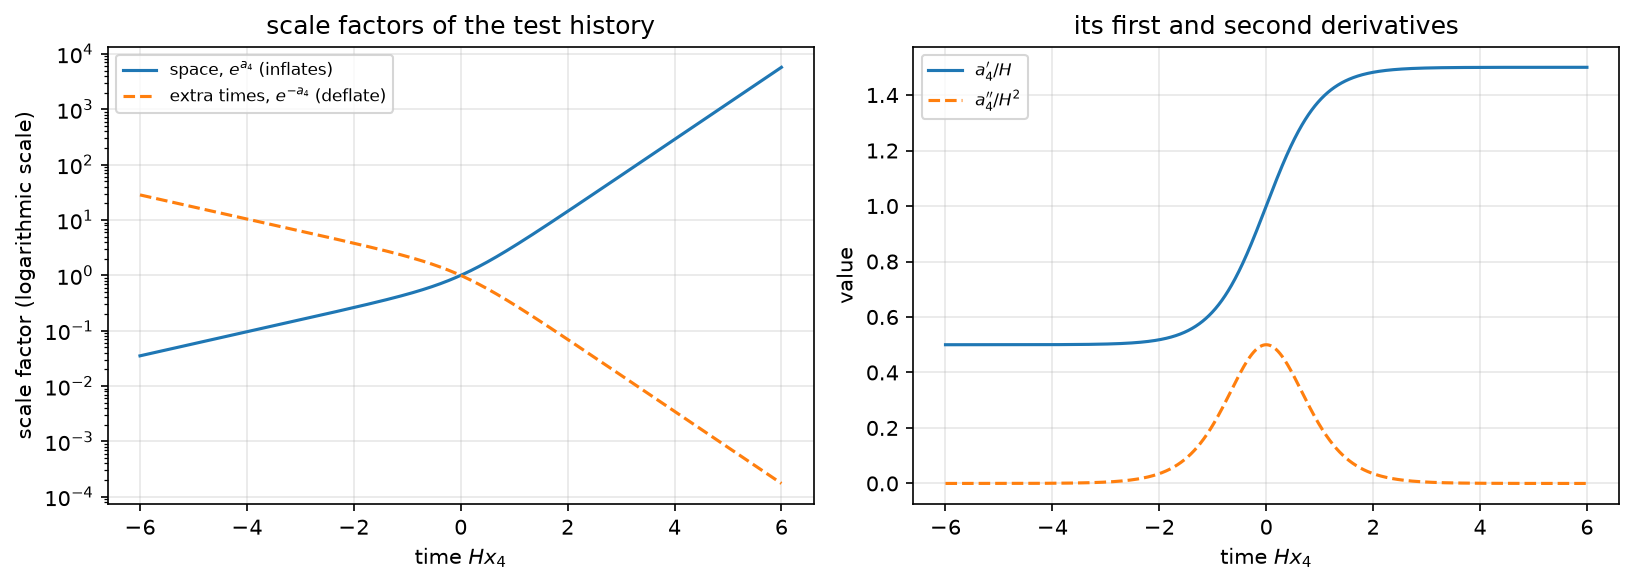

Figure 11c.3 saved as Revision/textbook/figures/11c_3_test_history.png


In [8]:
t = sp.Symbol("t")  # t = H x4 (the time in units of 1/H); H = 1 below
history = t + sp.log(sp.cosh(t)) / 2
first = sp.diff(history, t)  # a4' (with H = 1)
second = sp.diff(history, t, 2)  # a4''
check(sp.simplify(first - (1 + sp.tanh(t) / 2)) == 0
      and sp.simplify(second - sp.sech(t) ** 2 / 2) == 0,
      "the test history has a4' = 1 + tanh/2 > 0 and a4'' = sech^2/2 (H = 1)")
times = np.linspace(-6.0, 6.0, 1201)  # H x4 from -6 to 6
a4_values = sp.lambdify(t, history, "numpy")(times)
a1_values = sp.lambdify(t, first, "numpy")(times)
a2_values = sp.lambdify(t, second, "numpy")(times)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
axes[0].semilogy(times, np.exp(a4_values), label="space, $e^{a_4}$ (inflates)")
axes[0].semilogy(times, np.exp(-a4_values), "--",
                 label="extra times, $e^{-a_4}$ (deflate)")
axes[0].set_xlabel("time $H x_4$")
axes[0].set_ylabel("scale factor (logarithmic scale)")
axes[0].set_title("scale factors of the test history")
axes[0].legend(fontsize=8)
axes[1].plot(times, a1_values, label="$a_4^{\\prime}/H$")
axes[1].plot(times, a2_values, "--", label="$a_4^{\\prime\\prime}/H^2$")
axes[1].set_xlabel("time $H x_4$")
axes[1].set_ylabel("value")
axes[1].set_title("its first and second derivatives")
axes[1].legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "test_history",
            "The illustrative test history $a_4 = H x_4 + \\frac{1}{2} \\ln\\cosh H "
            "x_4$, not a solution of any field equation, against the time $H x_4$. "
            "Left: the scale factor $e^{a_4}$ of ordinary space (solid) grows and the "
            "scale factor $e^{-a_4}$ of the extra times (dashed) shrinks at all "
            "times, both on a logarithmic axis, where exponential change is a "
            "straight line: the slope steepens from $1/2$ to $3/2$ around $x_4 = 0$. "
            "Right: $a_4^{\\prime}/H$ rises from 1/2 to 3/2 and "
            "$a_4^{\\prime\\prime}/H^2$ is a bump of height 1/2 at $x_4 = 0$.")

The next cell evaluates the four independent components of $E_{(1)}, E_{(2)},
E_{(3)}$ along the test history (with $H = 1$, so in units of $H^{2k}$) and draws
them. Where $a_4''$ is not zero, the space component $E^{x1}_{x1}$ and the
extra-time component $E^{x5}_{x5}$ separate (their difference is
$a_4'' F_k(a_4')$), and the hidden component $E^{x8}_{x8}$ runs exactly in the
middle; far in the past and far in the future, where $a_4'' \to 0$, the three
coincide again. The check confirms the middle position at all 1201 times.

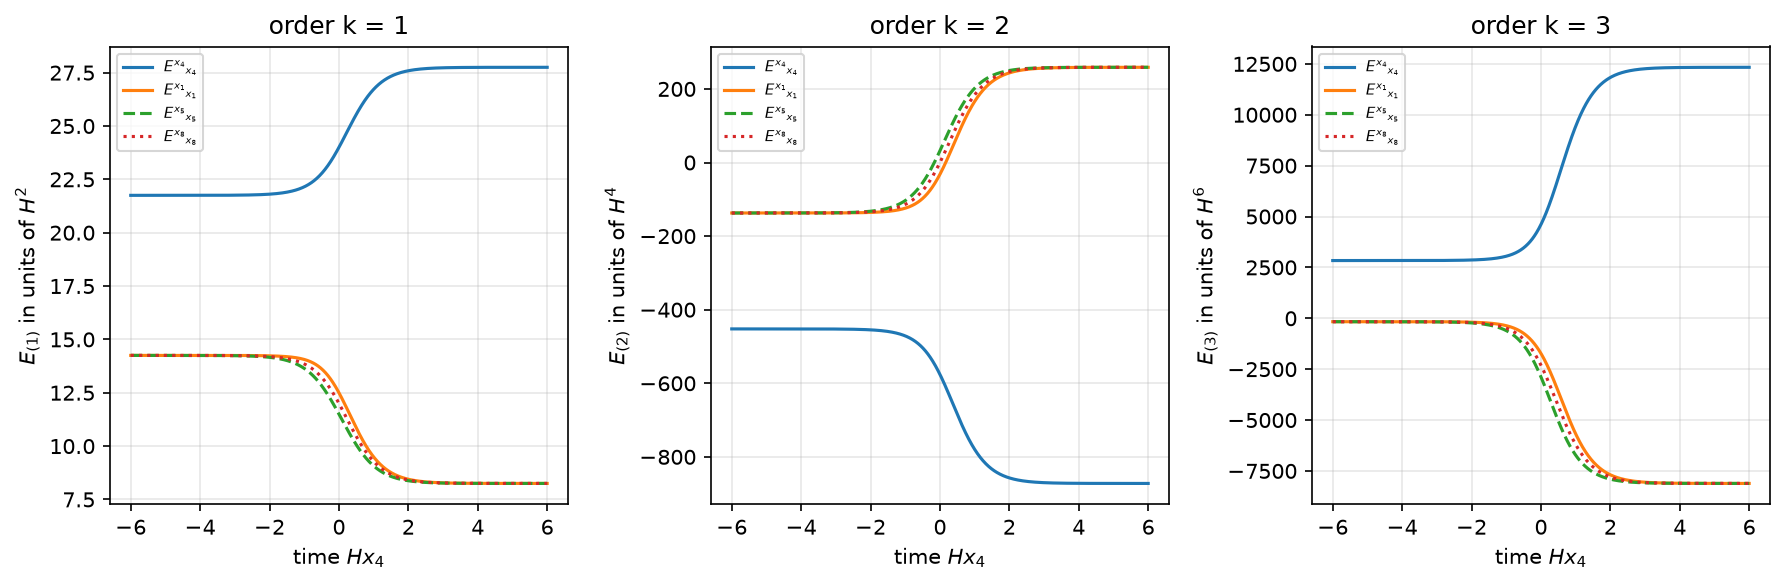

Figure 11c.4 saved as Revision/textbook/figures/11c_4_components_test_history.png
PASS along the test history E^x8_x8 is the mean of E^x1_x1 and E^x5_x5 at all 1201 times


In [9]:
def along_history(expr):
    """expr (H = 1) at every time of the test history."""
    function = sp.lambdify((A1, A2), expr.subs(H, 1), "numpy")
    return np.broadcast_to(function(a1_values, a2_values), times.shape).astype(float)


fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.0))
middle = True
curves = {}
for ax, k in zip(axes, (1, 2, 3)):
    curves[k] = {h: along_history(E[k][h, h]) for h in (0, 3, 4, 7)}
    middle &= np.allclose(curves[k][7], (curves[k][0] + curves[k][4]) / 2,
                          rtol=1e-12, atol=1e-9)
    for h, style in ((3, "-"), (0, "-"), (4, "--"), (7, ":")):
        ax.plot(times, curves[k][h], style,
                label=f"$E^{{x_{h + 1}}}{{}}_{{x_{h + 1}}}$")
    ax.set_xlabel("time $H x_4$")
    ax.set_ylabel(f"$E_{{({k})}}$ in units of $H^{{{2 * k}}}$")
    ax.set_title(f"order k = {k}")
    ax.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "components_test_history",
            "The four independent components of $E_{(1)}$, $E_{(2)}$ and $E_{(3)}$ "
            "along the illustrative test history, in units of $H^2$, $H^4$, $H^6$, "
            "against the time $H x_4$: the time component $E^{x_4}_{\\ x_4}$, the "
            "space component $E^{x_1}_{\\ x_1}$, the extra-time component "
            "$E^{x_5}_{\\ x_5}$ (dashed) and the hidden component "
            "$E^{x_8}_{\\ x_8}$ (dotted). Space and extra-time components separate "
            "where $a_4^{\\prime\\prime} \\neq 0$, by $a_4^{\\prime\\prime} "
            "F_k(a_4^{\\prime})$, and the hidden one lies exactly halfway between "
            "them; the time component depends on $a_4^{\\prime}$ only.")
check(middle, "along the test history E^x8_x8 is the mean of E^x1_x1 and E^x5_x5 "
              "at all 1201 times")

The last computation checks identity (I) NUMERICALLY along the test history, as an
independent confirmation of the exact proof of section 7: the derivative of the time
component, computed as a finite difference of the 1201 values
(`np.gradient` uses $(f(t + \epsilon) - f(t - \epsilon))/(2\epsilon)$ inside the
interval, with $\epsilon = 0.01$), must agree with $3a_4'(E^{x1}_{x1} -
E^{x5}_{x5})$ up to the error of the finite difference, which is of the order of
$\epsilon^2$ times the third derivative. The cell prints the largest deviation for
each order, relative to the largest value of the curve, and draws both sides.

RESULT order 1: largest relative deviation of the finite difference = 3.8e-05
RESULT order 2: largest relative deviation of the finite difference = 4.0e-05
RESULT order 3: largest relative deviation of the finite difference = 4.5e-05


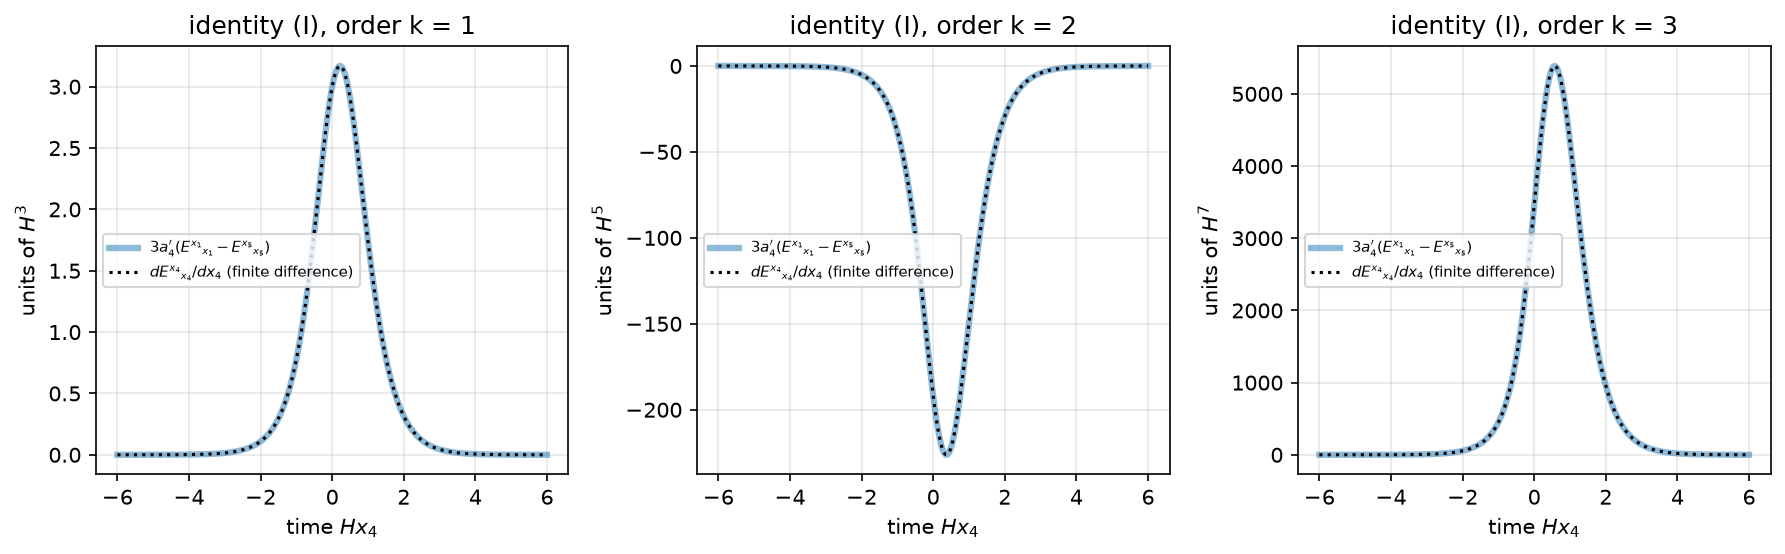

Figure 11c.5 saved as Revision/textbook/figures/11c_5_conservation_identity.png
PASS the finite-difference derivative agrees with identity (I) to 1e-4


In [10]:
step = times[1] - times[0]  # epsilon = 0.01
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8))
worst = {}
for ax, k in zip(axes, (1, 2, 3)):
    left = np.gradient(curves[k][3], step)  # d/dx4 of the time component
    right = 3 * a1_values * (curves[k][0] - curves[k][4])
    inner = slice(1, -1)  # the two end points use a one-sided difference
    worst[k] = float(np.max(np.abs(left[inner] - right[inner]))
                     / np.max(np.abs(right)))
    report(f"order {k}: largest relative deviation of the finite difference",
           f"{worst[k]:.1e}")
    ax.plot(times, right, color="tab:blue", lw=3, alpha=0.5,
            label="$3 a_4^{\\prime} (E^{x_1}{}_{x_1} - E^{x_5}{}_{x_5})$")
    ax.plot(times, left, "k:", label="$d E^{x_4}{}_{x_4} / d x_4$ (finite difference)")
    ax.set_xlabel("time $H x_4$")
    ax.set_ylabel(f"units of $H^{{{2 * k + 1}}}$")
    ax.set_title(f"identity (I), order k = {k}")
    ax.legend(fontsize=7)
fig.tight_layout()
largest = max(worst.values())  # the largest relative deviation of the three orders
power = int(np.floor(np.log10(largest)))  # its power of ten
deviation_text = f"${largest / 10 ** power:.1f} \\times 10^{{{power}}}$"
save_figure(fig, "conservation_identity",
            "Identity (I), the conservation identity along the time, checked "
            "numerically along the illustrative test history for $k = 1, 2, 3$: the "
            "finite-difference derivative of the time component $E^{x_4}_{\\ x_4}$ "
            "(dotted black) lies on $3 a_4^{\\prime} (E^{x_1}_{\\ x_1} - "
            "E^{x_5}_{\\ x_5})$ (thick blue), in units of $H^{2k+1}$, against the "
            "time $H x_4$. Both are zero where $a_4^{\\prime\\prime} = 0$ and peak "
            "where the deflation speeds up; the largest relative deviation is "
            f"about {deviation_text}, the size of the finite-difference error.")
check(all(value < 1e-4 for value in worst.values()),
      "the finite-difference derivative agrees with identity (I) to 1e-4")

The last cell checks that all five figure files exist and prints the number of
checks that passed.

In [11]:
figure_files = [f"11c_{k}_{name}.png" for k, name in enumerate(
    ["components_linear_history", "lovelock_scalars", "test_history",
     "components_test_history", "conservation_identity"], 1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_files),
      "all five figure files of the notebook exist")
all_checks_passed()

PASS all five figure files of the notebook exist
ALL 16 CHECKS PASSED (notebook 11c)


## 10. What this notebook showed

- The normalised Lovelock tensors of the author's metric are diagonal polynomials in
  $H$, $a_4'$ and $a_4''$, for example Einstein's tensor
  $E^{x1}_{x1} = -3a_4'^2 + a_4'' + 15H^2$, $E^{x4}_{x4} = 3a_4'^2 + 21H^2$,
  $E^{x5}_{x5} = -3a_4'^2 - a_4'' + 15H^2$, $E^{x8}_{x8} = -3a_4'^2 + 15H^2$; all
  three orders equal the components recorded for the field equations of $a_4$.
- Their structure (PROVED): space components equal, extra-time components equal;
  time and hidden components free of $a_4''$; the space minus extra-time difference
  is $a_4''$ times $F_1 = 2$, $F_2 = -16(3a_4'^2 + 5H^2)$, $F_3 = 144(5a_4'^4 +
  6a_4'^2H^2 + 5H^4)$; the hidden component is the mean of the space and extra-time
  components; everything is even in $a_4'$, so deflation of the extra times is not
  selected by these tensors; order $k$ has the dimension $1/\text{length}^{2k}$.
- The two conservation identities, $\frac{d}{dx_4}E^{x4}_{x4} = 3a_4'(E^{x1}_{x1} -
  E^{x5}_{x5})$ and $E^{x8}_{x8} = \frac12(E^{x1}_{x1} + E^{x5}_{x5})$, hold exactly
  for every order and were confirmed numerically along a test history.
- On the exponentially deflating linear history $a_4 = AHx_4$ only two different
  components remain (time, and all the others), even functions of $A$; the test
  history (an illustration only) shows that $a_4''$ separates the space and
  extra-time components while the hidden one stays halfway between them.